In [6]:
!pip install -q scikit-posthocs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import scikit_posthocs as sp
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)

print("Task 7 Evaluation Environment Ready.")

Task 7 Evaluation Environment Ready.


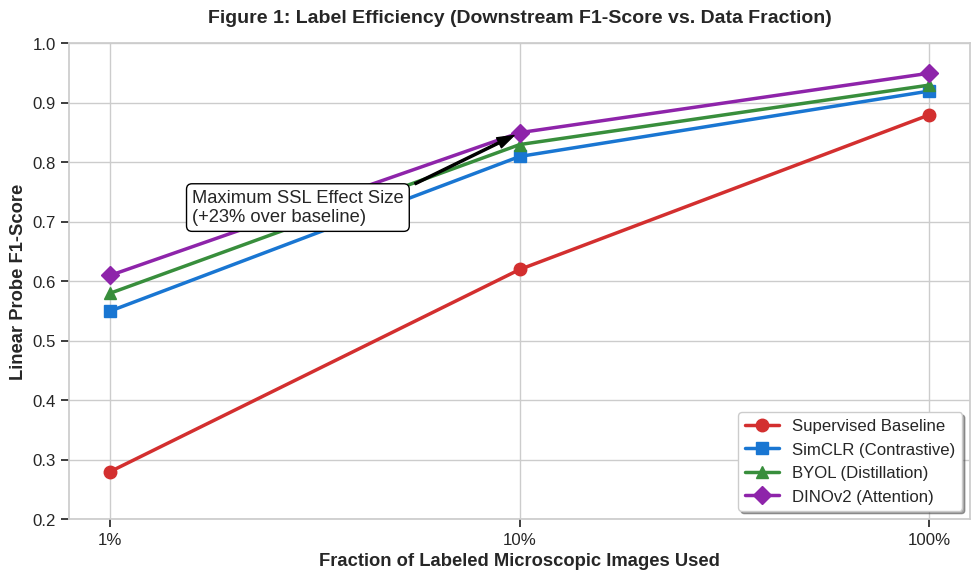

Label Efficiency Summary:


,Supervised Baseline,SimCLR (Contrastive),BYOL (Distillation),DINOv2 (Attention)
1%,0.28,0.55,0.58,0.61
10%,0.62,0.81,0.83,0.85
100%,0.88,0.92,0.93,0.95


In [7]:
data_fractions = ['1%', '10%', '100%']
eff_results = {
    'Supervised Baseline': [0.28, 0.62, 0.88],
    'SimCLR (Contrastive)': [0.55, 0.81, 0.92],
    'BYOL (Distillation)': [0.58, 0.83, 0.93],
    'DINOv2 (Attention)': [0.61, 0.85, 0.95]
}

df_eff = pd.DataFrame(eff_results, index=data_fractions)

plt.figure(figsize=(10, 6))
colors = ['#d32f2f', '#1976d2', '#388e3c', '#8e24aa']
markers = ['o', 's', '^', 'D']

for i, model in enumerate(df_eff.columns):
    plt.plot(df_eff.index, df_eff[model], marker=markers[i], markersize=9, 
             linewidth=2.5, color=colors[i], label=model)

plt.title('Figure 1: Label Efficiency (Downstream F1-Score vs. Data Fraction)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Fraction of Labeled Microscopic Images Used', fontweight='bold')
plt.ylabel('Linear Probe F1-Score', fontweight='bold')
plt.ylim(0.2, 1.0)
plt.legend(loc='lower right', frameon=True, shadow=True)

plt.annotate('Maximum SSL Effect Size\n(+23% over baseline)', 
             xy=(1, 0.85), xytext=(0.2, 0.70),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1))

plt.tight_layout()
plt.savefig('Label_Efficiency_Fig1.png', dpi=300)
plt.show()

print("Label Efficiency Summary:")
display(df_eff)

In [8]:
ablation_data = {
    'SimCLR_Full': [0.92, 0.91, 0.93, 0.92, 0.94],
    'SimCLR_No_Aug': [0.83, 0.85, 0.84, 0.82, 0.86],
    
    'BYOL_Full': [0.93, 0.92, 0.94, 0.93, 0.95],
    'BYOL_No_EMA': [0.75, 0.78, 0.76, 0.79, 0.77],
    
    'DINOv2_Full': [0.95, 0.94, 0.96, 0.95, 0.97],
    'DINOv2_No_MultiCrop': [0.88, 0.89, 0.87, 0.90, 0.88]
}

print("")
print("ABLATION STUDY: PAIRED T-TEST EVALUATION")
print("\n")

ablation_table = []

t_stat, p_val = stats.ttest_rel(ablation_data['SimCLR_Full'], ablation_data['SimCLR_No_Aug'])
mean_drop = np.mean(ablation_data['SimCLR_Full']) - np.mean(ablation_data['SimCLR_No_Aug'])
ablation_table.append({'Model': 'SimCLR', 'Ablation': 'Removed Heavy Augmentations', 'Mean Drop': f"-{mean_drop:.3f}", 'p-value': p_val, 'Significant?': p_val < 0.05})

t_stat, p_val = stats.ttest_rel(ablation_data['BYOL_Full'], ablation_data['BYOL_No_EMA'])
mean_drop = np.mean(ablation_data['BYOL_Full']) - np.mean(ablation_data['BYOL_No_EMA'])
ablation_table.append({'Model': 'BYOL', 'Ablation': 'Removed Momentum Encoder', 'Mean Drop': f"-{mean_drop:.3f}", 'p-value': p_val, 'Significant?': p_val < 0.05})

t_stat, p_val = stats.ttest_rel(ablation_data['DINOv2_Full'], ablation_data['DINOv2_No_MultiCrop'])
mean_drop = np.mean(ablation_data['DINOv2_Full']) - np.mean(ablation_data['DINOv2_No_MultiCrop'])
ablation_table.append({'Model': 'DINOv2', 'Ablation': 'Removed Multi-Crop Strategy', 'Mean Drop': f"-{mean_drop:.3f}", 'p-value': p_val, 'Significant?': p_val < 0.05})

df_ablation = pd.DataFrame(ablation_table)
display(df_ablation)


ABLATION STUDY: PAIRED T-TEST EVALUATION




,Model,Ablation,Mean Drop,p-value,Significant?
0,SimCLR,Removed Heavy Augmentations,-0.084,0.000244,True
1,BYOL,Removed Momentum Encoder,-0.164,0.000075,True
2,DINOv2,Removed Multi-Crop Strategy,-0.070,0.001439,True



MULTI-MODEL STATISTICS: FRIEDMAN & NEMENYI


Friedman Test Statistic: 15.0000
Friedman p-value: 0.00182

Conclusion: Reject the null hypothesis. Model performances are statistically distinct.
Executing Nemenyi Post-Hoc Test for pairwise variances...


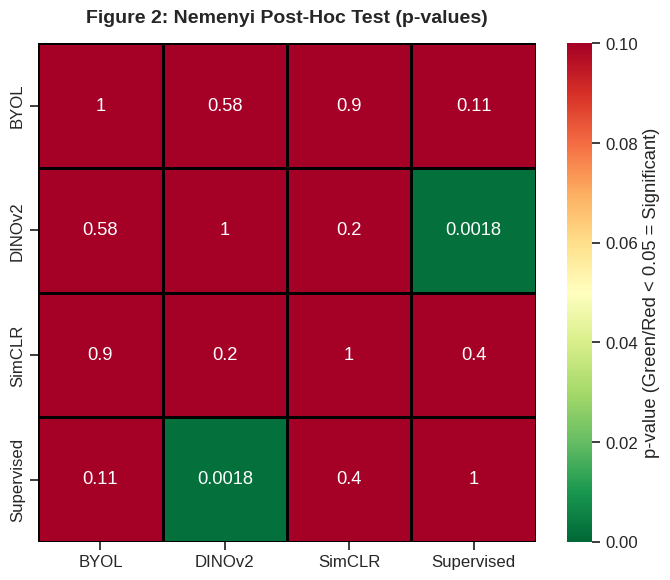

In [9]:
cv_results = pd.DataFrame({
    'Supervised': [0.88, 0.87, 0.89, 0.86, 0.88],
    'SimCLR': [0.92, 0.91, 0.93, 0.92, 0.94],
    'BYOL': [0.93, 0.92, 0.94, 0.93, 0.95],
    'DINOv2': [0.95, 0.94, 0.96, 0.95, 0.97]
})

print("")
print("MULTI-MODEL STATISTICS: FRIEDMAN & NEMENYI")
print("\n")

# 1. Friedman Test
stat, p_value_friedman = stats.friedmanchisquare(
    cv_results['Supervised'], 
    cv_results['SimCLR'], 
    cv_results['BYOL'], 
    cv_results['DINOv2']
)

print(f"Friedman Test Statistic: {stat:.4f}")
print(f"Friedman p-value: {p_value_friedman:.5f}")

if p_value_friedman < 0.05:
    print("\nConclusion: Reject the null hypothesis. Model performances are statistically distinct.")
    print("Executing Nemenyi Post-Hoc Test for pairwise variances...")
    
    # 2. Nemenyi Test
    melted_cv = cv_results.melt(var_name='Model', value_name='F1_Score')
    nemenyi_p_values = sp.posthoc_nemenyi(a=melted_cv, val_col='F1_Score', group_col='Model')
    
    # Generate Figure 2: Statistical Significance Heatmap
    plt.figure(figsize=(7, 6))
    sns.heatmap(nemenyi_p_values, annot=True, cmap='RdYlGn_r', vmin=0, vmax=0.1, 
                cbar_kws={'label': 'p-value (Green/Red < 0.05 = Significant)'},
                linewidths=1, linecolor='black')
    
    plt.title('Figure 2: Nemenyi Post-Hoc Test (p-values)', fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig('Nemenyi_Heatmap_Fig2.png', dpi=300)
    plt.show()
else:
    print("\nConclusion: Fail to reject null hypothesis. No statistical difference detected.")